In [6]:
import os
import time
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from transformers import XLMRobertaTokenizerFast, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

Using Device: cpu


In [ ]:
TEST_DATA_PATH = "../data/processed/test.csv"
LR_PATH = "../models/logistic_regression_baseline.joblib"
VECTORIZER_PATH = "../models/tfidf_vectorizer.joblib"
AFRO_XLMR_PATH = "../models/afro-xlmr-baseline"
LABEL_NAMES = ["Positive", "Neutral", "Negative"]

df_test = pd.read_csv("test.csv")
text = df_test["tweet"].astype(str).tolist()
label = df_test["label"]

def evaluate_saved_joblib_model(tfidf_path, baseline_path, text_data, label_data):
    print(f"\nLoading saved Traditional Baseline from: {baseline_path}")

    vectorizer = joblib.load(tfidf_path)
    model_pipeline = joblib.load(baseline_path)

    X_test = vectorizer.transform(text_data)

    start_time = time.time()
    preds = model_pipeline.predict(X_test)
    total_time = time.time() - start_time
    average_latency = (total_time / len(text_data)) * 1000

    precision, recall, f1, _ = precision_recall_fscore_support(
        label_data, preds, average="macro"
    )
    acc = accuracy_score(label_data, preds)

    metrics = {
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1, 4),
        "Macro Precision": round(precision, 4),
        "Macro Recall": round(recall, 4),
        "Average Latency": round(average_latency, 2),
    }

    return metrics, preds


def evaluate_models(model, text, label):
  print(f"Evaluating model: {model}")
  tokenizer = XLMRobertaTokenizerFast.from_pretrained(model)
  model = AutoModelForSequenceClassification.from_pretrained(model).to(device)
  model.to(device)
  model.eval()

  start_time = time.time()
  preds = []
  with torch.no_grad():
    chunks = [text[i:i + 50] for i in range(0, len(text), 50)]
    for chunk in chunks:
      inputs = tokenizer(chunk, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
      outputs = model(**inputs)
      pred_class = torch.argmax(outputs.logits, dim=-1).tolist()
      preds.extend(pred_class)
  total_time = time.time() - start_time
  average_latency = (total_time / len(text)) * 1000
  print(f"Average Latency: {average_latency:.2f} ms")

  precision, recall, f1, _ = precision_recall_fscore_support(label, preds, average="macro")
  acc = accuracy_score(label, preds)

  metrics = {"Accuracy": acc,"Macro F1":f1, "Macro Precision": precision, "Macro Recall": recall, "Average Latency": average_latency}
  return metrics, preds






Evaluating Traditional Baseline...

Loading saved Traditional Baseline from: logistic_regression_baseline.joblib

CLASSIFICATION REPORT: Traditional Baseline


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.6.1. This might lead to breaking c

              precision    recall  f1-score   support

    Positive     0.5556    0.5530    0.5543       434
     Neutral     0.1927    0.2727    0.2258        77
    Negative     0.7401    0.7117    0.7256       784

    accuracy                         0.6324      1295
   macro avg     0.4961    0.5125    0.5019      1295
weighted avg     0.6457    0.6324    0.6385      1295

Evaluating AFRO_XLMR...
Evaluating model: models/afro-xlmr-baseline


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Average Latency: 250.00 ms

CLASSIFICATION REPORT: AFRO_XLMR
              precision    recall  f1-score   support

    Positive     0.5878    0.6636    0.6234       434
     Neutral     0.2750    0.1429    0.1880        77
    Negative     0.7791    0.7602    0.7695       784

    accuracy                         0.6911      1295
   macro avg     0.5473    0.5222    0.5270      1295
weighted avg     0.6850    0.6911    0.6860      1295


       TRADITIONAL BASELINE VS AFRO-XLMR BASELINE


,Accuracy,Macro F1,Macro Precision,Macro Recall,Average Latency
Traditional Baseline,0.63240,0.50190,0.49610,0.512500,0.00000
AFRO_XLMR,0.69112,0.52698,0.54728,0.522219,250.00488


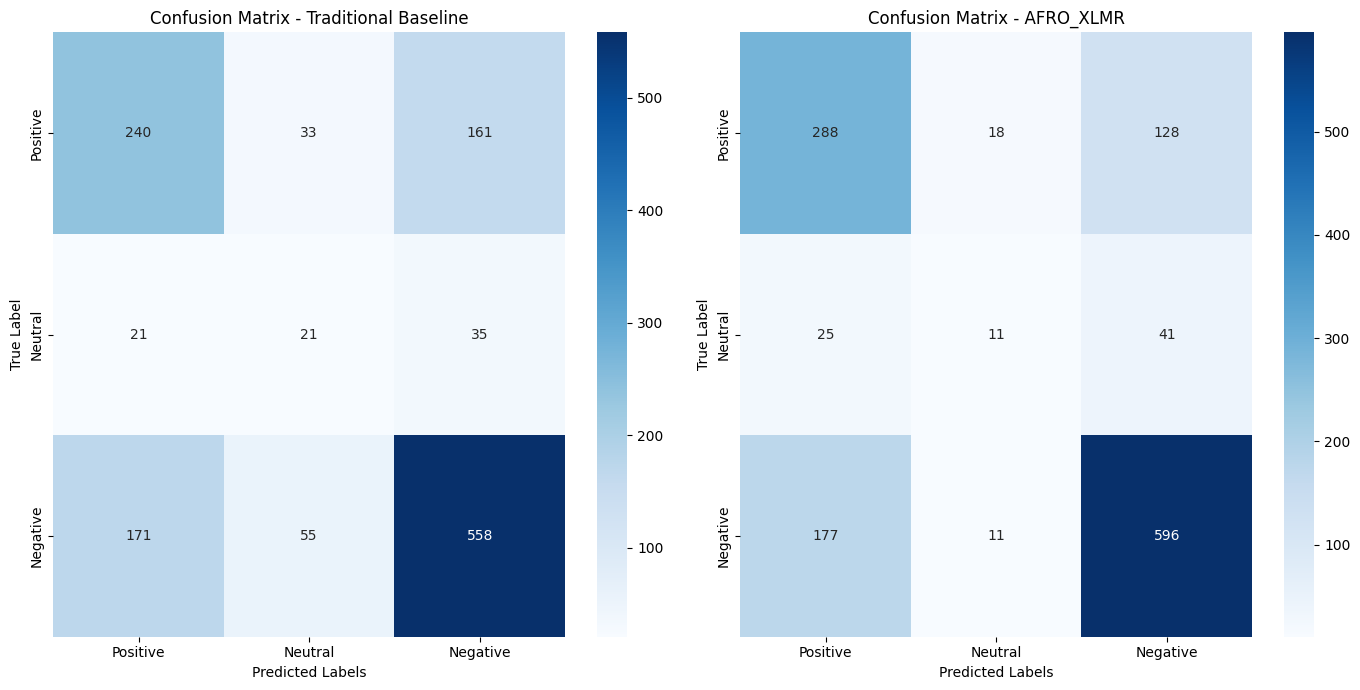

In [ ]:
results = {}
predictions = {}

print("Evaluating Traditional Baseline...")
name = "Traditional Baseline"
metrics, preds = evaluate_saved_joblib_model(VECTORIZER_PATH, LR_PATH, text, label)
results[name] = metrics
predictions[name] = preds

print("\n" + "=" * 55)
print(f"CLASSIFICATION REPORT: {name}")
print("=" * 55)
print(classification_report(label, preds, target_names=LABEL_NAMES, digits=4))

print("Evaluating AFRO_XLMR...")
name = "AFRO_XLMR"
metrics, preds = evaluate_models(AFRO_XLMR_PATH, text, label)
results[name] = metrics
predictions[name] = preds

print("\n" + "=" * 55)
print(f"CLASSIFICATION REPORT: {name}")
print("=" * 55)
print(classification_report(label, preds, target_names=LABEL_NAMES, digits=4))

comparison_df = pd.DataFrame(results).T
print("\n" + "=" * 55)
print("       TRADITIONAL BASELINE VS AFRO-XLMR BASELINE")
print("=" * 55)
display(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for idx, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(label, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
        ax=axes[idx],
    )
    axes[idx].set_title(f"Confusion Matrix - {name}")
    axes[idx].set_xlabel("Predicted Labels")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()